## SECTION 1 — Imports

In [1]:
import os
import glob
import random

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## SECTION 2 — Constants

In [17]:
# -----------------------------
# Dataset paths
# -----------------------------
AUDIO_DIR = "../ESC-50-master/audio/"
CSV_PATH = "../ESC-50-master/meta/esc50.csv"
REAL_MIC_DIR = "../ESC-50-master/real_mic_data/"

# -----------------------------
# Audio processing parameters
# MUST match the Flutter app exactly. DO NOT CHANGE.
# -----------------------------
SR = 22050
DURATION = 5
N_MELS = 64
MAX_PAD_LEN = 216
N_FFT = 2048
HOP_LENGTH = 512
TOP_DB = 80

# -----------------------------
# Class definitions
# -----------------------------
EMERGENCY_CLASSES = [
    "siren",
    "crying_baby",
    "door_wood_knock",
    "glass_breaking",
    "fireworks",
    "car_horn",
]

NEGATIVE_CLASSES = [
    "keyboard_typing",
    "footsteps",
    "clock_tick",
    "mouse_click",
    "rain",
    "wind",
    "breathing",
    "chirping_birds",
    "washing_machine",
    "laughing",
]

INCLUDE_NEGATIVE_CLASSES = True

ALL_CLASSES = EMERGENCY_CLASSES + (["background"] if INCLUDE_NEGATIVE_CLASSES else [])
NUM_CLASSES = len(ALL_CLASSES)

TARGET_CATEGORIES = EMERGENCY_CLASSES + (NEGATIVE_CLASSES if INCLUDE_NEGATIVE_CLASSES else [])

LABEL_MAP = {category: idx for idx, category in enumerate(EMERGENCY_CLASSES)}

if INCLUDE_NEGATIVE_CLASSES:
    background_idx = len(EMERGENCY_CLASSES) # Index 6
    LABEL_MAP["background"] = background_idx
    for neg_category in NEGATIVE_CLASSES:
        LABEL_MAP[neg_category] = background_idx

# --- FIXED HERE ---
INVERSE_LABEL_MAP = {idx: category for idx, category in enumerate(ALL_CLASSES)}

EMERGENCY_LABEL_IDS = {LABEL_MAP[c] for c in EMERGENCY_CLASSES if c in LABEL_MAP}
NEGATIVE_LABEL_IDS = {LABEL_MAP[c] for c in NEGATIVE_CLASSES if c in LABEL_MAP}

print(f"Emergency classes ({len(EMERGENCY_CLASSES)}): {EMERGENCY_CLASSES}")
print(f"Negative classes included: {INCLUDE_NEGATIVE_CLASSES}")
print(f"Total model output classes ({NUM_CLASSES}): {ALL_CLASSES}")

Emergency classes (6): ['siren', 'crying_baby', 'door_wood_knock', 'glass_breaking', 'fireworks', 'car_horn']
Negative classes included: True
Total model output classes (7): ['siren', 'crying_baby', 'door_wood_knock', 'glass_breaking', 'fireworks', 'car_horn', 'background']


## SECTION 3 — Audio Processing

Unchanged from the original pipeline — these parameters must stay pixel-for-pixel identical to what the Flutter app recreates.

In [3]:
def process_audio_to_mel(audio, sr,
                         n_mels=N_MELS,
                         max_pad_len=MAX_PAD_LEN):

    # Ensure exactly 5 seconds
    target_length = SR * DURATION

    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]

    # Compute mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=n_mels,
        power=2.0,
    )

    # Convert to dB
    mel_spec_db = librosa.power_to_db(
        mel_spec,
        ref=np.max,
        top_db=TOP_DB,
    )

    # Pad or trim to MAX_PAD_LEN frames
    if mel_spec_db.shape[1] < max_pad_len:
        pad = max_pad_len - mel_spec_db.shape[1]
        mel_spec_db = np.pad(
            mel_spec_db,
            ((0, 0), (0, pad)),
            mode="constant",
        )
    else:
        mel_spec_db = mel_spec_db[:, :max_pad_len]

    # Standardize each spectrogram
    mean = np.mean(mel_spec_db)
    std = np.std(mel_spec_db)

    mel_spec_db = (mel_spec_db - mean) / (std + 1e-6)

    return mel_spec_db.astype(np.float32)


## SECTION 4 — Data Augmentation

Two layers of augmentation, both applied only to the training split (see Section 8), never to validation or real-mic data:

1. **Waveform-level** — 10 independent techniques (up from 5). `augment_audio` now guarantees at least 2 stack per copy, so augmented samples don't collapse back toward near-duplicates of the original even when generating many copies per clip.
2. **Spectrogram-level (SpecAugment)** — frequency/time masking applied *after* `process_audio_to_mel`, in Section 8. This is effectively free extra diversity since it doesn't require re-decoding or re-transforming audio.

In [4]:
from scipy.signal import butter, sosfiltfilt, iirpeak, fftconvolve

# ------------------------------------------------------------------
# Waveform-level augmentations
# ------------------------------------------------------------------

# Add white noise
def add_noise(data):
    noise_factor = random.uniform(0.001, 0.008)
    noise = np.random.randn(len(data))
    augmented = data + noise_factor * noise
    return np.clip(augmented, -1.0, 1.0)

# Add pink-ish noise (low-frequency-weighted)
def add_pink_noise(data):
    noise_factor = random.uniform(0.001, 0.006)
    white = np.random.randn(len(data))
    pink = np.cumsum(white)
    pink = pink / (np.max(np.abs(pink)) + 1e-9)
    augmented = data + noise_factor * pink
    return np.clip(augmented, -1.0, 1.0)

# Random pitch shift
def pitch_shift(data, sr):
    steps = random.uniform(-2, 2)
    return librosa.effects.pitch_shift(
        y=data,
        sr=sr,
        n_steps=steps,
    )

# Random speed change
def time_stretch(data):
    rate = random.uniform(0.90, 1.10)
    stretched = librosa.effects.time_stretch(
        data,
        rate=rate,
    )
    if len(stretched) > len(data):
        stretched = stretched[:len(data)]
    else:
        stretched = np.pad(
            stretched,
            (0, len(data) - len(stretched)),
        )
    return stretched

# Random volume
def random_gain(data):
    gain = random.uniform(0.8, 1.2)
    augmented = data * gain
    return np.clip(augmented, -1.0, 1.0)

# Random time shift
def time_shift(data):
    shift = random.randint(
        -int(0.15 * len(data)),
        int(0.15 * len(data)),
    )
    return np.roll(data, shift)

# Flip waveform polarity
def polarity_invert(data):
    return -data

# Random band-pass filter
def bandpass_filter(data, sr):
    low = random.uniform(50, 300)
    high = random.uniform(4000, min(8000.0, sr / 2 - 100))
    sos = butter(4, [low, high], btype="bandpass", fs=sr, output="sos")
    return sosfiltfilt(sos, data).astype(np.float32)

# Fade in/out envelope
def fade_in_out(data):
    length = len(data)
    fade_len = max(1, int(length * random.uniform(0.05, 0.2)))
    envelope = np.ones(length)
    envelope[:fade_len] = np.linspace(0, 1, fade_len)
    envelope[-fade_len:] = np.linspace(1, 0, fade_len)
    return data * envelope

# Randomly silence a short waveform segment
def random_silence_gap(data):
    length = len(data)
    gap_len = max(1, int(length * random.uniform(0.02, 0.08)))
    start = random.randint(0, length - gap_len)
    augmented = np.copy(data)
    augmented[start:start + gap_len] = 0.0
    return augmented

# ------------------------------------------------------------------
# "Real phone microphone" channel simulators
# ------------------------------------------------------------------

# Synthetic room reverb
def add_reverb(data, sr):
    decay = random.uniform(0.15, 0.6)
    wet_mix = random.uniform(0.15, 0.45)
    n_ir = max(1, int(sr * decay))
    t = np.arange(n_ir) / sr
    ir = np.random.randn(n_ir) * np.exp(-t / (decay / 4))
    ir = ir / (np.max(np.abs(ir)) + 1e-9)
    wet = fftconvolve(data, ir, mode="full")[:len(data)]
    wet = wet / (np.max(np.abs(wet)) + 1e-9) * (np.max(np.abs(data)) + 1e-9)
    augmented = (1 - wet_mix) * data + wet_mix * wet
    return np.clip(augmented, -1.0, 1.0).astype(np.float32)

# Random phone-mic frequency coloring
def mic_coloring_filter(data, sr):
    center_freq = random.uniform(800, 4000)
    q = random.uniform(1.0, 4.0)
    gain_db = random.uniform(-6, 6)
    b, a = iirpeak(center_freq, q, fs=sr)
    colored = sosfiltfilt(np.array([[b[0], b[1], b[2], a[0], a[1], a[2]]]), data)
    mix = np.clip(abs(gain_db) / 6.0, 0.0, 1.0)
    if gain_db >= 0:
        augmented = data + mix * (colored - data)
    else:
        augmented = data - mix * (colored - data)

    cutoff = random.uniform(6000, min(9500.0, sr / 2 - 100))
    sos = butter(2, cutoff, btype="lowpass", fs=sr, output="sos")
    augmented = sosfiltfilt(sos, augmented)
    return np.clip(augmented, -1.0, 1.0).astype(np.float32)

# Simulate lossy codec / low-bitrate transmission artifacts
def codec_compression_artifact(data, sr):
    bit_depth = random.choice([6, 7, 8])
    levels = 2 ** bit_depth
    quantized = np.round(data * levels) / levels
    cutoff = random.uniform(5000, min(8000.0, sr / 2 - 100))
    sos = butter(3, cutoff, btype="lowpass", fs=sr, output="sos")
    augmented = sosfiltfilt(sos, quantized)
    return np.clip(augmented, -1.0, 1.0).astype(np.float32)

# Simulate dynamic range compressor
def dynamic_range_compress(data):
    drive = random.uniform(1.5, 4.0)
    compressed = np.tanh(data * drive) / np.tanh(drive)
    return np.clip(compressed, -1.0, 1.0).astype(np.float32)

# Waveform augmentations
_WAVEFORM_AUGMENTATIONS = [
    lambda a, sr: add_noise(a),
    lambda a, sr: add_pink_noise(a),
    lambda a, sr: pitch_shift(a, sr),
    lambda a, sr: time_stretch(a),
    lambda a, sr: random_gain(a),
    lambda a, sr: time_shift(a),
    lambda a, sr: polarity_invert(a),
    lambda a, sr: fade_in_out(a),
    lambda a, sr: random_silence_gap(a),
]

# Channel simulators
_CHANNEL_AUGMENTATIONS = [
    lambda a, sr: bandpass_filter(a, sr),
    lambda a, sr: add_reverb(a, sr),
    lambda a, sr: mic_coloring_filter(a, sr),
    lambda a, sr: codec_compression_artifact(a, sr),
    lambda a, sr: dynamic_range_compress(a),
]

# Random augmentation pipeline
def augment_audio(data, sr, apply_prob=0.4, min_ops=2, channel_prob=0.6):
    audio = np.copy(data)
    applied = 0
    order = list(_WAVEFORM_AUGMENTATIONS)
    random.shuffle(order)
    for fn in order:
        if random.random() < apply_prob:
            audio = fn(audio, sr)
            applied += 1
    if applied < min_ops:
        for fn in random.sample(order, min_ops - applied):
            audio = fn(audio, sr)

    channel_order = list(_CHANNEL_AUGMENTATIONS)
    random.shuffle(channel_order)
    channel_applied = 0
    for fn in channel_order:
        if channel_applied == 0 or random.random() < channel_prob:
            audio = fn(audio, sr)
            channel_applied += 1
    return audio

# ------------------------------------------------------------------
# Spectrogram-level augmentation (SpecAugment)
# ------------------------------------------------------------------
def spec_freq_mask(mel_db, num_masks=1, max_width=8):
    mel_db = mel_db.copy()
    n_mels = mel_db.shape[0]
    fill_value = mel_db.min()
    for _ in range(num_masks):
        width = random.randint(1, max_width)
        start = random.randint(0, max(0, n_mels - width))
        mel_db[start:start + width, :] = fill_value
    return mel_db

def spec_time_mask(mel_db, num_masks=1, max_width=16):
    mel_db = mel_db.copy()
    n_frames = mel_db.shape[1]
    fill_value = mel_db.min()
    for _ in range(num_masks):
        width = random.randint(1, max_width)
        start = random.randint(0, max(0, n_frames - width))
        mel_db[:, start:start + width] = fill_value
    return mel_db

def apply_spec_augment(mel_db, prob=0.5):
    if random.random() < prob:
        mel_db = spec_freq_mask(mel_db)
    if random.random() < prob:
        mel_db = spec_time_mask(mel_db)
    return mel_db

## SECTION 5 — Load ESC-50

Loads **only** `ALL_CLASSES` (emergency + negative) from ESC-50. This is the key change from the original notebook, which only ever loaded the 6 emergency classes.

In [5]:
print("Loading ESC-50 clips...")
raw_clips = []

df = pd.read_csv(CSV_PATH)
df_filtered = df[df["category"].isin(TARGET_CATEGORIES)].reset_index(drop=True)

missing_classes = set(TARGET_CATEGORIES) - set(df_filtered["category"].unique())
if missing_classes:
    print(f"WARNING: these classes were not found in {CSV_PATH}: {missing_classes}")

for _, row in df_filtered.iterrows():
    path = os.path.join(AUDIO_DIR, row["filename"])
    try:
        audio, sr = librosa.load(path, sr=SR, res_type="kaiser_fast")
        # Maps specific negative events (e.g., 'rain') to the 'background' index (6)
        label = LABEL_MAP[row["category"]] 
        raw_clips.append((audio, sr, label))
    except Exception as e:
        print(f"Warning: {path} - {e}")

print(f"Loaded {len(raw_clips)} ESC-50 clips across {len(TARGET_CATEGORIES)} raw classes mapping to {NUM_CLASSES} output labels")

# Per-class counts, useful to catch missing/short categories early
counts = pd.Series([INVERSE_LABEL_MAP[c[2]] for c in raw_clips]).value_counts()
print("\nPer-label clip counts:")
print(counts.reindex(ALL_CLASSES))

Loading ESC-50 clips...


c:\Users\ACER\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ACER\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ACER\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


Loaded 640 ESC-50 clips across 16 raw classes mapping to 7 output labels

Per-label clip counts:
siren               40
crying_baby         40
door_wood_knock     40
glass_breaking      40
fireworks           40
car_horn            40
background         400
Name: count, dtype: int64


## SECTION 6 — Load Real Microphone Dataset

These recordings are **never** used for training or validation — held out purely for final, real-world evaluation (Section 13). Only folders that actually exist under `REAL_MIC_DIR` are loaded, so this works whether you only have recordings for the emergency classes or have also started collecting negative-class recordings.

In [6]:
print("\nLoading real microphone clips (held-out evaluation set only)...")
real_test_clips = []

for category in TARGET_CATEGORIES:
    class_dir = os.path.join(REAL_MIC_DIR, category)
    if not os.path.isdir(class_dir):
        continue  # no real-mic recordings collected for this class yet

    files = glob.glob(os.path.join(class_dir, "*"))
    for path in files:
        try:
            audio, sr = librosa.load(path, sr=SR, res_type="kaiser_fast")
            target_len = SR * DURATION
            if len(audio) < target_len:
                audio = np.pad(audio, (0, target_len - len(audio)))
            else:
                audio = audio[:target_len]
            real_test_clips.append((audio, sr, LABEL_MAP[category]))
        except Exception as e:
            print(f"Warning: {path} - {e}")

print(f"Loaded {len(real_test_clips)} real microphone clips for evaluation")

if real_test_clips:
    real_counts = pd.Series([INVERSE_LABEL_MAP[c[2]] for c in real_test_clips]).value_counts()
    print("\nPer-class real-mic clip counts:")
    print(real_counts)
else:
    print("No real microphone recordings found under REAL_MIC_DIR.")


Loading real microphone clips (held-out evaluation set only)...
Loaded 30 real microphone clips for evaluation

Per-class real-mic clip counts:
siren              5
crying_baby        5
door_wood_knock    5
glass_breaking     5
fireworks          5
car_horn           5
Name: count, dtype: int64


## SECTION 7 — Train / Validation Split

Stratified split on ESC-50 clips only. Real microphone recordings are never part of this split.

In [7]:
labels_only = [c[2] for c in raw_clips]

train_idx, val_idx = train_test_split(
    range(len(raw_clips)),
    test_size=0.2,
    random_state=SEED,
    stratify=labels_only,
)

train_raw = [raw_clips[i] for i in train_idx]
val_raw = [raw_clips[i] for i in val_idx]

print(f"ESC-50 split: Train {len(train_raw)} | Val {len(val_raw)}")


ESC-50 split: Train 512 | Val 128


## SECTION 8 — Build Dataset

Augmentation is applied **only** to the training set. Validation and real-mic data are processed with `process_audio_to_mel` alone — never augmented.

`AUGMENT_TIMES` controls how many augmented copies are generated per original training clip (raised from 6 to 14, so the training set is now ~15x the raw clip count instead of ~7x). Since Section 4 now has 10 waveform techniques plus SpecAugment masking to draw from, the extra copies stay meaningfully different from each other instead of being near-duplicates. This will make training noticeably slower — lower `AUGMENT_TIMES` if that becomes a problem.

In [8]:
# Number of augmented copies generated per original training clip.
# Total training-set multiplier = 1 (original) + AUGMENT_TIMES.
AUGMENT_TIMES = 14


def build_augmented_set(raw_set, augment=False, augment_times=AUGMENT_TIMES, use_spec_augment=True):

    X = []
    y = []

    for audio, sr, label in raw_set:

        # Always include the original, unaugmented clip
        X.append(process_audio_to_mel(audio, sr))
        y.append(label)

        if augment:
            for _ in range(augment_times):
                augmented_audio = augment_audio(audio, sr)
                mel_db = process_audio_to_mel(augmented_audio, sr)
                if use_spec_augment:
                    mel_db = apply_spec_augment(mel_db)
                X.append(mel_db)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    return X, y


print("Building training set (augmented)...")
X_train, y_train = build_augmented_set(
    train_raw,
    augment=True,
    augment_times=AUGMENT_TIMES,
    use_spec_augment=True,
)

print("Building validation set (no augmentation)...")
X_val, y_val = build_augmented_set(
    val_raw,
    augment=False,
)

print("Building real-world evaluation set (no augmentation)...")
X_real_test, y_real_test = build_augmented_set(
    real_test_clips,
    augment=False,
)

X_train = X_train.reshape(-1, X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(-1, X_val.shape[1], X_val.shape[2], 1)
if len(X_real_test) > 0:
    X_real_test = X_real_test.reshape(-1, X_real_test.shape[1], X_real_test.shape[2], 1)

print(f"\nTrain shape: {X_train.shape}")
print(f"Val shape: {X_val.shape}")
print(f"Real-world eval shape: {X_real_test.shape}")


Building training set (augmented)...
Building validation set (no augmentation)...
Building real-world evaluation set (no augmentation)...

Train shape: (7680, 64, 216, 1)
Val shape: (128, 64, 216, 1)
Real-world eval shape: (30, 64, 216, 1)


## SECTION 9 — Verify Preprocessing

Sanity checks before spending time training: correct tensor shape for the Flutter model input `(64, 216, 1)`, no NaN/Inf values, sensible value ranges, class balance across splits, and a visual check of a spectrogram.

X_train: shape=(7680, 64, 216, 1), min=-8.701, max=11.325, mean=-0.098
X_val: shape=(128, 64, 216, 1), min=-5.879, max=10.311, mean=0.000
X_real_test: shape=(30, 64, 216, 1), min=-4.662, max=4.057, mean=-0.000

Input tensor shape matches Flutter model input (64, 216, 1): OK

Train label distribution:
siren               480
crying_baby         480
door_wood_knock     480
glass_breaking      480
fireworks           480
car_horn            480
background         4800
Name: count, dtype: int64

Validation label distribution:
siren               8
crying_baby         8
door_wood_knock     8
glass_breaking      8
fireworks           8
car_horn            8
background         80
Name: count, dtype: int64

Real-mic label distribution:
siren              5
crying_baby        5
door_wood_knock    5
glass_breaking     5
fireworks          5
car_horn           5
Name: count, dtype: int64


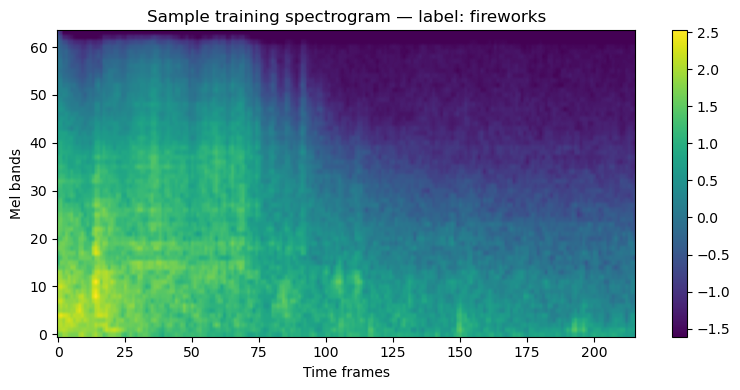

In [9]:
expected_shape = (N_MELS, MAX_PAD_LEN, 1)

assert X_train.shape[1:] == expected_shape, f"Train shape mismatch: {X_train.shape[1:]} != {expected_shape}"
assert X_val.shape[1:] == expected_shape, f"Val shape mismatch: {X_val.shape[1:]} != {expected_shape}"
if len(X_real_test) > 0:
    assert X_real_test.shape[1:] == expected_shape, f"Real-mic shape mismatch: {X_real_test.shape[1:]} != {expected_shape}"

for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_real_test", X_real_test)]:
    if len(arr) == 0:
        continue
    assert not np.isnan(arr).any(), f"{name} contains NaN values"
    assert not np.isinf(arr).any(), f"{name} contains Inf values"
    print(f"{name}: shape={arr.shape}, min={arr.min():.3f}, max={arr.max():.3f}, mean={arr.mean():.3f}")

print("\nInput tensor shape matches Flutter model input (64, 216, 1): OK")

# Class balance across splits
print("\nTrain label distribution:")
print(pd.Series(y_train).map(INVERSE_LABEL_MAP).value_counts().reindex(ALL_CLASSES))

print("\nValidation label distribution:")
print(pd.Series(y_val).map(INVERSE_LABEL_MAP).value_counts().reindex(ALL_CLASSES))

if len(y_real_test) > 0:
    print("\nReal-mic label distribution:")
    print(pd.Series(y_real_test).map(INVERSE_LABEL_MAP).value_counts())

# Visual check of one processed spectrogram
sample_idx = 0
plt.figure(figsize=(8, 4))
plt.imshow(X_train[sample_idx, :, :, 0], aspect="auto", origin="lower")
plt.title(f"Sample training spectrogram — label: {INVERSE_LABEL_MAP[y_train[sample_idx]]}")
plt.xlabel("Time frames")
plt.ylabel("Mel bands")
plt.colorbar()
plt.tight_layout()
plt.show()


## SECTION 10 — Build CNN

Same architecture as before. The only functional change is the output layer size: `len(ALL_CLASSES)` instead of `len(EMERGENCY_CLASSES)`, since the model now has more classes to separate.

In [10]:
model = models.Sequential([

    layers.Input(shape=(N_MELS, MAX_PAD_LEN, 1)),

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.50),

    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 216, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 216, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 216, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 27, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 27, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,983 (433.53 KB)

 Trainable params: 110,535 (431.78 KB)

 Non-trainable params: 448 (1.75 KB)

## SECTION 11 — Train

In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

print("\nTraining...")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=16,
    shuffle=True,
    callbacks=[early_stopping, reduce_lr, checkpoint],
)

# Load the best saved model
model = tf.keras.models.load_model("best_model.keras")



Training...
Epoch 1/80
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6377 - loss: 1.2266
Epoch 1: val_accuracy improved from -inf to 0.67188, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 43s 84ms/step - accuracy: 0.6377 - loss: 1.2264 - val_accuracy: 0.6719 - val_loss: 1.0961 - learning_rate: 5.0000e-04
Epoch 2/80
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6934 - loss: 0.9551
Epoch 2: val_accuracy improved from 0.67188 to 0.72656, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.6934 - loss: 0.9551 - val_accuracy: 0.7266 - val_loss: 0.8399 - learning_rate: 5.0000e-04
Epoch 3/80
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7142 - loss: 0.8649
Epoch 3: val_accuracy improved from 0.72656 to 0.76562, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.7142 - loss: 0.8649 - val_accuracy: 0.7656 - val_loss: 0.7607 - learning_rate: 5.0000e-04
Epoch 4/80
480/480 ━━

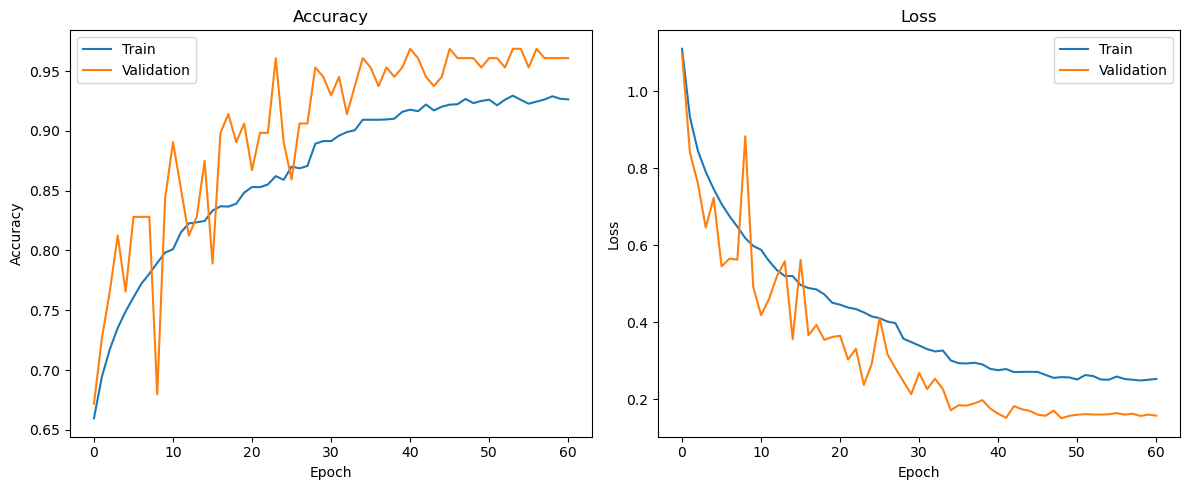

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## SECTION 12 — Evaluation (ESC-50 Validation Set)

Three views are reported:
1. **Full multi-class report** across all `ALL_CLASSES` — this is what the model actually outputs.
2. **Emergency vs. non-emergency rollup** — collapses the 16 classes into a binary "is this an emergency?" decision. This tells you how often a negative-class sound gets pulled into *any* emergency label, regardless of which one.
3. **Leak report** — a full confusion matrix is hard to read once you have 16 classes. This zooms in on just the `EMERGENCY_CLASSES` and shows, in plain terms, (a) when an emergency clip is missed, what it gets predicted as instead (*recall leak* — who is stealing its recall), and (b) when the model predicts an emergency class, what the clip actually was when it's wrong (*precision leak* — what's contaminating that prediction, i.e. a direct false-alarm source).

In [13]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)

print("=" * 60)
print("VALIDATION SET PERFORMANCE (ESC-50, all classes)")
print("=" * 60)
print(classification_report(y_val, y_val_pred, target_names=ALL_CLASSES, zero_division=0))
print("Confusion Matrix (rows=true, cols=pred), order = ALL_CLASSES:")
print(confusion_matrix(y_val, y_val_pred, labels=list(range(NUM_CLASSES))))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
VALIDATION SET PERFORMANCE (ESC-50, all classes)
                 precision    recall  f1-score   support

          siren       1.00      0.75      0.86         8
    crying_baby       1.00      1.00      1.00         8
door_wood_knock       1.00      1.00      1.00         8
 glass_breaking       1.00      1.00      1.00         8
      fireworks       0.80      1.00      0.89         8
       car_horn       0.89      1.00      0.94         8
     background       0.99      0.97      0.98        80

       accuracy                           0.97       128
      macro avg       0.95      0.96      0.95       128
   weighted avg       0.97      0.97      0.97       128

Confusion Matrix (rows=true, cols=pred), order = ALL_CLASSES:
[[ 6  0  0  0  0  1  1]
 [ 0  8  0  0  0  0  0]
 [ 0  0  8  0  0  0  0]
 [ 0  0  0  8  0  0  0]
 [ 0  0  0  0  8  0  0]
 [ 0  0  0  0  0  8  0]
 [ 0  0  0  0  2  0 78]]


In [14]:
def to_binary_emergency(labels):
    return np.array([1 if l in EMERGENCY_LABEL_IDS else 0 for l in labels])

if INCLUDE_NEGATIVE_CLASSES:
    y_val_binary_true = to_binary_emergency(y_val)
    y_val_binary_pred = to_binary_emergency(y_val_pred)

    print("\n" + "=" * 60)
    print("VALIDATION SET — EMERGENCY vs NON-EMERGENCY ROLLUP")
    print("=" * 60)
    print(classification_report(
        y_val_binary_true, y_val_binary_pred,
        target_names=["non_emergency", "emergency"],
        zero_division=0,
    ))
    print("Confusion Matrix ([non_emergency, emergency]):")
    print(confusion_matrix(y_val_binary_true, y_val_binary_pred))
else:
    print("Skipping emergency vs non-emergency rollup — no negative classes in this run "
          "(every class is an emergency class right now, so the rollup would be trivial).")



VALIDATION SET — EMERGENCY vs NON-EMERGENCY ROLLUP
               precision    recall  f1-score   support

non_emergency       0.99      0.97      0.98        80
    emergency       0.96      0.98      0.97        48

     accuracy                           0.98       128
    macro avg       0.97      0.98      0.98       128
 weighted avg       0.98      0.98      0.98       128

Confusion Matrix ([non_emergency, emergency]):
[[78  2]
 [ 1 47]]


In [19]:
def leak_report(y_true, y_pred, focus_classes=EMERGENCY_CLASSES):
    y_true_idx = np.argmax(y_true, axis=1) if y_true.ndim > 1 else y_true
    y_pred_idx = np.argmax(y_pred, axis=1) if y_pred.ndim > 1 else y_pred

    for cls in focus_classes:
        cls_idx = LABEL_MAP[cls]
        mask = (y_true_idx == cls_idx)
        n = np.sum(mask)
        if n == 0:
            continue
        
        wrong = y_pred_idx[mask & (y_pred_idx != cls_idx)]
        n_wrong = len(wrong)
        
        print(f"\nClass: {cls} (total samples: {n})")
        print(f"  Accuracy: {100 * (n - n_wrong) / n:.1f}%")
        print(f"  Misclassified: {n_wrong}/{n}")
        
        if n_wrong > 0:
            wrong_counts = pd.Series(wrong).map(INVERSE_LABEL_MAP).value_counts()
            for name, count in wrong_counts.items():
                # Direct check against EMERGENCY_CLASSES string list
                tag = "EMERGENCY" if name in EMERGENCY_CLASSES else "negative"
                print(f"    -> leaked to {name:20s} ({tag:9s}): {count} ({100 * count / n:.0f}%)")


print("VALIDATION SET — LEAK REPORT (EMERGENCY_CLASSES)")
print("=" * 60)
leak_report(y_val, y_val_pred, focus_classes=EMERGENCY_CLASSES)

VALIDATION SET — LEAK REPORT (EMERGENCY_CLASSES)

Class: siren (total samples: 8)
  Accuracy: 75.0%
  Misclassified: 2/8
    -> leaked to car_horn             (EMERGENCY): 1 (12%)
    -> leaked to background           (negative ): 1 (12%)

Class: crying_baby (total samples: 8)
  Accuracy: 100.0%
  Misclassified: 0/8

Class: door_wood_knock (total samples: 8)
  Accuracy: 100.0%
  Misclassified: 0/8

Class: glass_breaking (total samples: 8)
  Accuracy: 100.0%
  Misclassified: 0/8

Class: fireworks (total samples: 8)
  Accuracy: 100.0%
  Misclassified: 0/8

Class: car_horn (total samples: 8)
  Accuracy: 100.0%
  Misclassified: 0/8


## SECTION 13 — Real Microphone Evaluation

Evaluated only on the classes actually present in `REAL_MIC_DIR` (typically just the emergency classes, unless you've also collected real-mic negative-class recordings). This set is never touched during training or validation.

Includes the same leak report as Section 12 — this is the more important of the two, since it's the one that reflects real deployment conditions rather than clean ESC-50 studio audio.

In [18]:
if len(y_real_test) > 0:
    y_real_pred = np.argmax(model.predict(X_real_test), axis=1)

    present_label_ids = sorted(set(y_real_test) | set(y_real_pred))
    present_class_names = [INVERSE_LABEL_MAP[i] for i in present_label_ids]

    print("=" * 60)
    print("REAL-WORLD TEST PERFORMANCE (Phone Microphone Recordings)")
    print("=" * 60)
    print(f"(n={len(y_real_test)})")
    print(classification_report(
        y_real_test, y_real_pred,
        labels=present_label_ids,
        target_names=present_class_names,
        zero_division=0,
    ))
    print("Confusion Matrix:")
    print(confusion_matrix(y_real_test, y_real_pred, labels=present_label_ids))

    # Binary rollup on real-mic data too, since this is the number that
    # matters most for the deployed app's false-positive rate. Only
    # meaningful once negative classes are back in the mix.
    if INCLUDE_NEGATIVE_CLASSES:
        y_real_binary_true = to_binary_emergency(y_real_test)
        y_real_binary_pred = to_binary_emergency(y_real_pred)

        print("\n" + "=" * 60)
        print("REAL-WORLD TEST — EMERGENCY vs NON-EMERGENCY ROLLUP")
        print("=" * 60)
        print(classification_report(
            y_real_binary_true, y_real_binary_pred,
            target_names=["non_emergency", "emergency"],
            zero_division=0,
        ))
        print("Confusion Matrix ([non_emergency, emergency]):")
        print(confusion_matrix(y_real_binary_true, y_real_binary_pred))
    else:
        print("\nSkipping emergency vs non-emergency rollup — no negative classes in this run.")

    print("\n" + "=" * 60)
    print("REAL-WORLD TEST — LEAK REPORT (EMERGENCY_CLASSES)")
    print("=" * 60)
    leak_report(y_real_test, y_real_pred, focus_classes=EMERGENCY_CLASSES)
else:
    print("No real-world microphone clips loaded — skipping real-mic evaluation.")
    print("(REAL_MIC_DIR must never be used for training/validation, only here.)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
REAL-WORLD TEST PERFORMANCE (Phone Microphone Recordings)
(n=30)
                 precision    recall  f1-score   support

          siren       1.00      0.80      0.89         5
    crying_baby       1.00      0.60      0.75         5
door_wood_knock       0.00      0.00      0.00         5
 glass_breaking       0.00      0.00      0.00         5
      fireworks       0.00      0.00      0.00         5
       car_horn       1.00      0.80      0.89         5
     background       0.00      0.00      0.00         0

       accuracy                           0.37        30
      macro avg       0.43      0.31      0.36        30
   weighted avg       0.50      0.37      0.42        30

Confusion Matrix:
[[4 0 0 0 0 0 1]
 [0 3 0 0 0 0 2]
 [0 0 0 0 0 0 5]
 [0 0 0 0 0 0 5]
 [0 0 0 0 0 0 5]
 [0 0 0 0 0 4 1]
 [0 0 0 0 0 0 0]]

REAL-WORLD TEST — EMERGENCY vs NON-EMERGENCY ROLLUP
               precision    recall  f1-score   support

non_emergency      

## SECTION 14 — Export TensorFlow Lite

`labels.txt` is written in `ALL_CLASSES` order, which matches the model's output layer exactly. **This is a breaking change for the Flutter app**: the output size grows from 6 to 16 classes, so the app's label list and any index-based logic need to be updated to match `labels.txt` before this model is deployed.

In [20]:
print("Exporting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("emergency_audio_classifier.tflite", "wb") as f:
    f.write(tflite_model)

with open("labels.txt", "w") as f:
    for category in ALL_CLASSES:
        f.write(f"{category}\n")

print("Saved: emergency_audio_classifier.tflite")
print("Saved: labels.txt")
print(f"\nModel outputs {NUM_CLASSES} classes in this order:")
for idx, category in enumerate(ALL_CLASSES):
    tag = "EMERGENCY" if idx in EMERGENCY_LABEL_IDS else "negative"
    print(f"  {idx}: {category} ({tag})")


Exporting to TFLite...
INFO:tensorflow:Assets written to: C:\Users\ACER\AppData\Local\Temp\tmpetzo5qvj\assets


INFO:tensorflow:Assets written to: C:\Users\ACER\AppData\Local\Temp\tmpetzo5qvj\assets


Saved artifact at 'C:\Users\ACER\AppData\Local\Temp\tmpetzo5qvj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 216, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2290571112144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290571107152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290571108688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290571108304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290571112528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290571107344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290571109072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290571110224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290571113872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2290571111568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  22905711